In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
from pathlib import Path
import cell2location

from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42 # enables correct plotting of text for PDFs

mpl.rcParams['text.color'] = "black"
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams["savefig.facecolor"] = 'white'
sc.set_figure_params(dpi_save=300)

# silence scanpy that prints a lot of warnings
import warnings
warnings.filterwarnings('ignore')


/home/dengyq/conda/envs/cell2location_gpu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
results_folder = './10X_results/'

# create paths and names to results folders for reference regression and cell2location models
ref_run_name = f'{results_folder}/reference_signatures'
run_name = f'{results_folder}/cell2location_map'

In [3]:
def read_and_qc(sample_name, path):
    r""" This function reads the data for one 10X spatial experiment into the anndata object.
    It also calculates QC metrics. Modify this function if required by your workflow.

    :param sample_name: Name of the sample
    :param path: path to data
    """

    adata = sc.read_visium(path + '/'+ str(sample_name) + '-spatial/',
                           count_file=sample_name + '-filtered_feature_bc_matrix.h5',
                           library_id=sample_name,
                           load_images=True)
    adata.obs['sample'] = sample_name
    adata.var['SYMBOL'] = adata.var_names
    adata.var.rename(columns={'gene_ids': 'ENSEMBL'}, inplace=True)
    adata.var_names = adata.var['ENSEMBL']
    adata.var.drop(columns='ENSEMBL', inplace=True)
    adata.var_names = adata.var['SYMBOL']
    # adata.var_names_make_unique()
    adata = adata[:, ~adata.var_names.duplicated()].copy()
    adata.var_names.name = None

    # Calculate QC metrics
    from scipy.sparse import csr_matrix
    adata.X = adata.X.toarray()
    sc.pp.calculate_qc_metrics(adata, inplace=True)
    adata.X = csr_matrix(adata.X)
    adata.var['mt'] = [gene.startswith('mt-') for gene in adata.var['SYMBOL']]
    adata.obs['mt_frac'] = adata[:, adata.var['mt'].tolist()].X.sum(1).A.squeeze()/adata.obs['total_counts']

    # add sample name to obs names
    adata.obs["sample"] = [str(i) for i in adata.obs['sample']]
    # adata.obs_names = adata.obs["sample"] \
                        #   + '_' + adata.obs_names
    adata.obs.index.name = 'spot_id'

    return adata

def select_slide(adata, s, s_col='sample'):
    r""" This function selects the data for one slide from the spatial anndata object.

    :param adata: Anndata object with multiple spatial experiments
    :param s: name of selected experiment
    :param s_col: column in adata.obs listing experiment name for each location
    """

    slide = adata[adata.obs[s_col].isin([s]), :]
    s_keys = list(slide.uns['spatial'].keys())
    s_spatial = np.array(s_keys)[[s in k for k in s_keys]][0]

    slide.uns['spatial'] = {s_spatial: slide.uns['spatial'][s_spatial]}

    return slide

In [4]:
samples_name = os.listdir("10X_ST")

In [5]:
samples_name = [s.replace("-spatial", "") for s in samples_name]

In [6]:
#######################
# Read the data into anndata objects
slides = []
for i in samples_name:
    slides.append(read_and_qc(path='10X_ST', sample_name=i))


# Combine anndata objects together
adata = slides[0].concatenate(
    slides[1:],
    batch_key="sample",
    uns_merge="unique",
    batch_categories=samples_name,
    # index_unique=True
)

In [7]:
adata_vis = adata.copy()
adata_vis.raw = adata_vis

In [8]:
adata_vis.var_names = adata.var['SYMBOL'] 

In [9]:
adata_vis_plt = adata_vis.copy()

# Log-transform (log(data + 1))
sc.pp.log1p(adata_vis_plt)

# Find highly variable genes within each sample
adata_vis_plt.var['highly_variable'] = False
for s in adata_vis_plt.obs['sample'].unique():

    adata_vis_plt_1 = adata_vis_plt[adata_vis_plt.obs['sample'].isin([s]), :]
    sc.pp.highly_variable_genes(adata_vis_plt_1, min_mean=0.0125, max_mean=5, min_disp=0.5, n_top_genes=1000)

    hvg_list = list(adata_vis_plt_1.var_names[adata_vis_plt_1.var['highly_variable']])
    adata_vis_plt.var.loc[hvg_list, 'highly_variable'] = True

# Scale the data ( (data - mean) / sd )
sc.pp.scale(adata_vis_plt, max_value=10)
# PCA, KNN construction, UMAP
sc.tl.pca(adata_vis_plt, svd_solver='arpack', n_comps=40, use_highly_variable=True)
sc.pp.neighbors(adata_vis_plt, n_neighbors = 20, n_pcs = 40, metric='cosine')
sc.tl.umap(adata_vis_plt, min_dist = 0.3, spread = 1)

with mpl.rc_context({'figure.figsize': [8, 8],
                     'axes.facecolor': 'white'}):
    sc.pl.umap(adata_vis_plt, color=['sample'], size=30,
               legend_fontsize=10, show = False,
               frameon=False)
    plt.savefig("umap_sample_ST_before.pdf", bbox_inches="tight")
    plt.close()

In [10]:
adata_ref = sc.read_h5ad("NSCLC_ALL.h5ad")  

In [11]:
hvgs = adata_ref.var["highly_variable"]
adata_ref.var['SYMBOL'] = adata_ref.var.index


In [13]:
adata_ref = adata_ref.raw.to_adata()
adata_ref = adata_ref[:,hvgs]


In [16]:
cell2location.models.RegressionModel.setup_anndata(adata=adata_ref,
                        # 10X reaction / sample / batch
                        batch_key='orig.ident',
                        # cell type, covariate used for constructing signatures
                        labels_key='celltype_LV2',
                        # multiplicative technical effects (platform, 3' vs 5', donor effect)
                        # categorical_covariate_keys=['Method']
                       )

In [17]:
from cell2location.models import RegressionModel
mod = RegressionModel(adata_ref)


In [18]:
mod.train(max_epochs=250, batch_size = 4096, accelerator="gpu")

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 250/250: 100%|██████████| 250/250 [40:55<00:00,  9.90s/it, v_num=1, elbo_train=2.15e+8]

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 250/250: 100%|██████████| 250/250 [40:55<00:00,  9.82s/it, v_num=1, elbo_train=2.15e+8]


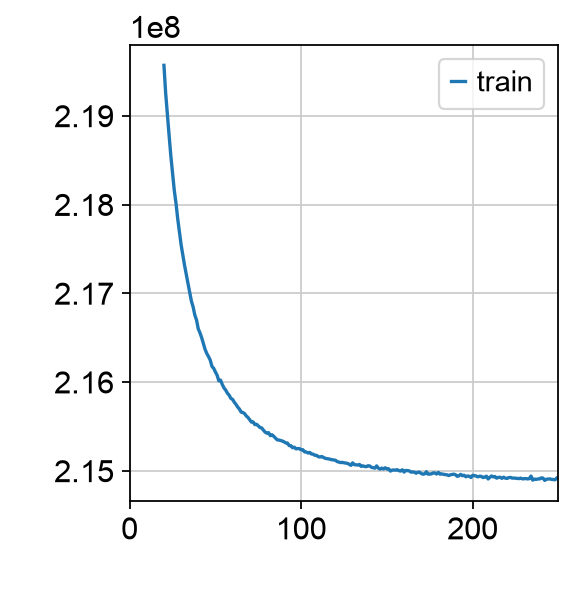

In [19]:
mod.plot_history(20)

In [20]:
# In this section, we export the estimated cell abundance (summary of the posterior distribution).
adata_ref = mod.export_posterior(
    adata_ref, sample_kwargs={'num_samples': 1000, 'batch_size': 2500}
)

# Save model
mod.save(f"{ref_run_name}", overwrite=True)

# Save anndata object with results
adata_file = f"{ref_run_name}/sc.h5ad"
adata_ref.write(adata_file)


Sampling global variables, sample: 100%|██████████| 999/999 [00:08<00:00, 118.37it/s]


In [21]:
adata_ref = mod.export_posterior(
    adata_ref, 
    use_quantiles=True,
    # choose quantiles
    add_to_varm=["q05","q50", "q95", "q0001"],
    sample_kwargs={'batch_size': 2500}
)

In [22]:
adata_file = f"{ref_run_name}/sc.h5ad"
adata_ref = sc.read_h5ad(adata_file)
mod = cell2location.models.RegressionModel.load(f"{ref_run_name}", adata_ref)

# export estimated expression in each cluster
if 'means_per_cluster_mu_fg' in adata_ref.varm.keys():
    inf_aver = adata_ref.varm['means_per_cluster_mu_fg'][[f'means_per_cluster_mu_fg_{i}'
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
else:
    inf_aver = adata_ref.var[[f'means_per_cluster_mu_fg_{i}'
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
inf_aver.columns = adata_ref.uns['mod']['factor_names']
# inf_aver

INFO     File ./10X_results//reference_signatures/model.pt already downloaded                                      


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/37:   3%|▎         | 1/37 [00:00<00:03,  9.25it/s, v_num=1]

`Trainer.fit` stopped: `max_steps=1` reached.


Epoch 1/37:   3%|▎         | 1/37 [00:00<00:04,  8.64it/s, v_num=1]


In [23]:
# find shared genes and subset both anndata and reference signatures
intersect = np.intersect1d(adata_vis.var_names, inf_aver.index)
# np.unique(intersect).shape
intersect.shape


adata_vis = adata_vis[:, intersect].copy()
inf_aver  = inf_aver.loc[intersect, :].copy()


# prepare anndata for cell2location model
cell2location.models.Cell2location.setup_anndata(adata=adata_vis, batch_key="sample")


# create and train the model
mod = cell2location.models.Cell2location(
    adata_vis, 
    cell_state_df=inf_aver,
    # the expected average cell abundance: tissue-dependent
    # hyper-prior which can be estimated from paired histology:
    N_cells_per_location=5,
    # hyperparameter controlling normalisation of
    # within-experiment variation in RNA detection:
    detection_alpha=200
)

# mod.view_anndata_setup()

mod.train(max_epochs=1000,
          # train using full data (batch_size=None)
          batch_size=None,
          # use all data points in training because
          # we need to estimate cell abundance at all locations
          train_size=1,
        #   use_gpu=True,
         )



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 153/1000:  15%|█▌        | 152/1000 [00:45<04:09,  3.40it/s, v_num=1, elbo_train=1.17e+8]

Epoch 1000/1000: 100%|██████████| 1000/1000 [04:54<00:00,  3.40it/s, v_num=1, elbo_train=6.25e+7]

`Trainer.fit` stopped: `max_epochs=1000` reached.


Epoch 1000/1000: 100%|██████████| 1000/1000 [04:54<00:00,  3.39it/s, v_num=1, elbo_train=6.25e+7]


In [24]:
adata_vis = mod.export_posterior(
    adata_vis,
    sample_kwargs={'num_samples': 1000, 'batch_size': mod.adata.n_obs}
)

Sampling global variables, sample: 100%|██████████| 999/999 [00:35<00:00, 27.94it/s]


In [25]:
adata_vis.obs[adata_vis.uns['mod']['factor_names']] = adata_vis.obsm['q05_cell_abundance_w_sf']

In [26]:
out_dir = "/home/dengyq/sdata/10X_results/cell2location_plots"
os.makedirs(out_dir, exist_ok=True)

In [27]:

sub = adata_vis[adata_vis.obs["sample"] == samples_name[0]].copy()

[<Axes: title={'center': 'AT1'}, xlabel='spatial1', ylabel='spatial2'>]

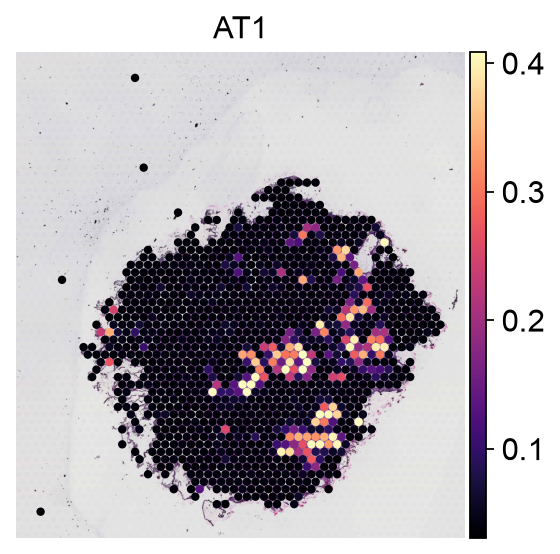

In [29]:
factor_names = list(adata_vis.uns['mod']['factor_names'])

sc.pl.spatial(sub, color=factor_names[0], library_id=samples_name[0], img_key="hires", size=1.5, color_map="magma", vmax="p99", frameon=False, show=False)

In [30]:
def sanitize(name):
    return (name.replace(" ", "_").replace("+", "p").replace("/", "_").replace(":", "_").replace("-", "_"))

for s in samples_name:
    sub = adata_vis[adata_vis.obs["sample"] == s].copy()
    for ct in factor_names:
        sc.pl.spatial(sub, color=ct, library_id=s, size=1.5,
                    frameon=False, show=False)
        fname = os.path.join(out_dir, f"{s}_{sanitize(ct)}.pdf")
        plt.savefig(fname, bbox_inches="tight")   
        plt.close()
    print(f"complited {s}")

complited P11_T1
complited P10_T2
complited P25_B2
complited P25_T1
complited P16_T2
complited P24_T2
complited P10_T3
complited P17_B1
complited P16_B1
complited P19_T1
complited P11_B2
complited P10_T4
complited P10_T1
complited P15_T1
complited P19_T2
complited P25_B1
complited P10_B2
complited P15_T2
complited P24_T1
complited P19_B1
complited P17_T1
complited P15_B1
complited P10_B1
complited P19_B2
complited P16_B2
complited P11_T2
complited P11_T3
complited P24_B2
complited P11_T4
complited P25_T2
complited P17_T2
complited P24_B1
complited P15_B2
complited P11_B1
complited P17_B2
complited P16_T1


In [31]:
adata_vis.write_h5ad("sp_all.h5ad", compression="gzip")


In [ ]:
for s in adata_vis.obs["sample"].unique():

      img_dict = adata_vis.uns["spatial"][s]["images"]
      img_key = "hires" if "hires" in img_dict else "lowres"  
      img = img_dict[img_key]


      fig, ax = plt.subplots(figsize=(6, 6))
      ax.imshow(img)
      ax.axis("off")
      plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
      plt.savefig(os.path.join(out_dir, f"{s}_tissue.png"), dpi=300)
      plt.close()
      print(f"completed {s}")

completed P11_T1
completed P10_T2
completed P25_B2
completed P25_T1
completed P16_T2
completed P24_T2
completed P10_T3
completed P17_B1
completed P16_B1
completed P19_T1
completed P11_B2
completed P10_T4
completed P10_T1
completed P15_T1
completed P19_T2
completed P25_B1
completed P10_B2
completed P15_T2
completed P24_T1
completed P19_B1
completed P17_T1
completed P15_B1
completed P10_B1
completed P19_B2
completed P16_B2
completed P11_T2
completed P11_T3
completed P24_B2
completed P11_T4
completed P25_T2
completed P17_T2
completed P24_B1
completed P15_B2
completed P11_B1
completed P17_B2
completed P16_T1


In [33]:
sc.pp.neighbors(adata_vis, use_rep='q05_cell_abundance_w_sf',
                n_neighbors = 15)

In [ ]:
# Cluster spots into regions using scanpy
sc.tl.leiden(adata_vis, resolution=1.1)

# add region as categorical variable
adata_vis.obs["region_cluster"] = adata_vis.obs["leiden"].astype("category")

In [ ]:
# compute UMAP using KNN graph based on the cell2location output
sc.tl.umap(adata_vis, min_dist = 0.3, spread = 1)

# show regions in UMAP coordinates
with mpl.rc_context({'axes.facecolor':  'white',
                     'figure.figsize': [8, 8]}):
    sc.pl.umap(adata_vis,  size=30, color = "sample",
               legend_fontsize=10, show = False,
               frameon=False)
    plt.savefig("umap_sample_q05.pdf", bbox_inches="tight")
    plt.close()
